# finetune

https://github.com/mims-harvard/PINNACLE/blob/e3d2fced3bb812141e76a947351e25fbafb7ce6b/finetune_pinnacle/README.md

In [1]:
cd /home/yang1641/PINNACLE/finetune_pinnacle

/home/yang1641/PINNACLE/finetune_pinnacle


In [2]:
import pandas as pd
import numpy as np
import os, wandb, random

from setup import create_parser, get_hparams, setup_paths
from read_data import load_data
from train_utils import training_and_validation
from metrics_utils import get_metrics, save_torch_train_val_preds, save_results
from data_prep import process_and_split_data

import torch
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import shuffle
os.environ['OPENBLAS_NUM_THREADS'] = '1'


/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)  # To display full content of each column

## first try: the args below were the default setup

## second try: try changing the args according to pinnacle github

https://github.com/mims-harvard/PINNACLE/blob/main/finetune_pinnacle/run_model.sh

## third try: use downloaded embedding (somewhat reproduced)

## [ongoing] fourth try: using my embedding

In [4]:
# see https://github.com/mims-harvard/PINNACLE/blob/main/pinnacle/run_pinnacle.sh
# and https://github.com/mims-harvard/PINNACLE/blob/main/pinnacle/parse_args.py


args_manual = {
    'actn':'relu', 
    'batch_size': None, 
    'data_split_path': '/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/data_split_EFO_0003767', 
    'dropout': 0.4,  
    'embed': 'try2', 
#     'embed': 'pinnacle',
    'embeddings_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/', 
#     'embeddings_dir': '/scratch/gilbreth/yang1641/exome/data/PINNACLE/pinnacle_embeds/',
    'hidden_dim_1': 32, 
    'hidden_dim_2': 8, 
    'hidden_dim_3': 0, 
    'lr': 0.001, 
#     'metrics_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/tmp_evaluation_results', 
    'metrics_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/',
#     'models_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/tmp_model_outputs', 
    'models_output_dir': '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/',
    'negative_proteins_prefix':'/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/negative_proteins_EFO_0003767', 
    'norm':'ln', 
    'num_epoch':2000, 
    'order':'nd', 
    'overwrite':False, 
    'positive_proteins_prefix':'/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767', 
    'random':False, 
    'random_state':100, 
    'task_name':'EFO_0003767', 
    'train_size':0.6, 'val_size':0.2, 
    'wd':0.0001, 'weigh_loss':False, 'weigh_sample':False
              }

## define a function to run the finetune for 10 times

In [5]:
def update_args_output_dir(args):
    args.metrics_output_dir = '/'.join((args.metrics_output_dir.split('/'))[:-1] + [args.task_name] + ['tmp_evaluation_results', ''])
    args.models_output_dir = '/'.join((args.models_output_dir.split('/'))[:-1] + [args.task_name] + ['tmp_model_outputs', ''])
    os.makedirs(args.metrics_output_dir, exist_ok = True)
    os.makedirs(args.models_output_dir, exist_ok = True)
    return args

In [6]:
import argparse

# Convert dictionary to argparse Namespace
args = argparse.Namespace(**args_manual)

args = update_args_output_dir(args)

print(args)

Namespace(actn='relu', batch_size=None, data_split_path='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/data_split_EFO_0003767', dropout=0.4, embed='try2', embeddings_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/', hidden_dim_1=32, hidden_dim_2=8, hidden_dim_3=0, lr=0.001, metrics_output_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_evaluation_results/', models_output_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_model_outputs/', negative_proteins_prefix='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/negative_proteins_EFO_0003767', norm='ln', num_epoch=2000, order='nd', overwrite=False, positive_proteins_prefix='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767', random=False, random_state=100, task_name='EFO_0003767', train_size=0.6, val_size=0.2, wd=0.0001, w

In [7]:
from train import run_finetune

def finetune_embed(args, _random_state):
    args.random_state = _random_state
    args.random = False
    
    np.random.seed(args.random_state)
    random.seed(args.random_state)
    torch.manual_seed(args.random_state)
    torch.cuda.manual_seed(args.random_state)
    torch.backends.cudnn.deterministic = True
    
    # initialize wandb session with session name
    hparams = get_hparams(args)
    print(hparams)
    
    wandb.login(key="f362484a2783a681fd551a00093aad3ce3139d4a")
    wandb.init(config=hparams, 
#                project="pinnacle_finetune_EFO_0003767_IBD", 
               project = '_'.join(['pinnacle_finetune', args.task_name, 'IBD', 'random_state', str(_random_state)]),
               allow_val_change=True)
    hparams = wandb.config
    
    # Set up model environment and data/model paths
    models_output_dir, metrics_output_dir, random_state, embed_path, labels_path = setup_paths(args)
    
    print(models_output_dir)
    print(metrics_output_dir)
    
    os.makedirs(models_output_dir, exist_ok=True)
    os.makedirs(metrics_output_dir, exist_ok=True)
    
    # Load data
    print(embed_path)
    embed, celltype_dict, celltype_protein_dict, positive_proteins, negative_proteins, _ = load_data(
        embed_path, labels_path, args.positive_proteins_prefix, 
        args.negative_proteins_prefix, None, args.task_name)
    print("Finished reading data, evaluating...\n")
    
    # Run model
    data_split_path = args.data_split_path + ".json"
    (positive_proportion_train, positive_count_train, total_count_train, 
     positive_proportion_test, positive_count_test, total_count_test, 
     auroc_scores, ap_scores, apr_at_5, apr_at_10, 
     ap_at_5, ap_at_10) = run_finetune(
        embed, celltype_dict, celltype_protein_dict, positive_proteins, negative_proteins, 
        data_split_path, random_state, models_output_dir, args.embed, hparams, args.batch_size, 
        args.num_epoch, args.train_size, args.val_size, args.weigh_sample, args.weigh_loss)
    
    # Generate outputs and plots
    print("Finished evaluation, generating plots...\n")
    output_results_path = os.path.join(
        metrics_output_dir, 
        f"{args.embed}_{args.task_name}_random_state_{args.random_state}_results.csv")
    
    output_figs_path = os.path.join(metrics_output_dir, f"{args.embed}_{args.task_name}_")
    
    res = {'ap': ap_scores, 'auroc': auroc_scores, 
           'apr_at_5': apr_at_5, 'apr_at_10': apr_at_10, 
           'ap_at_5': ap_at_5, 'ap_at_10': ap_at_10, 
           'positive_proportion_train': positive_proportion_train, 
           'positive_count_train': positive_count_train, 
           'total_count_train': total_count_train, 
           'positive_proportion_test': positive_proportion_test, 
           'positive_count_test': positive_count_test, 
           'total_count_test': total_count_test
          }
    
    return res, output_results_path

In [8]:
from functools import reduce

def finetune_embed_output_processing(res, output_results_path):
    output_summary_df_lst = []
    for k in res.keys():
        if 'train' not in k:
            output_summary_df_lst.append(
                pd.DataFrame(list(res[k].items()), columns=['cell', k])
            )
    output_summary_df = reduce(lambda x, y: x.merge(y, on='cell'), output_summary_df_lst)
    output_summary_df.to_csv(output_results_path, index=False)
    
    return output_summary_df

# TODO: why >5k in val AUROC (neither 20k nor 2k)

In [ ]:
for _random_state in range(1,11):
    print(_random_state)
    res, output_results_path = finetune_embed(args, _random_state)
    output_summary_df = finetune_embed_output_processing(res, output_results_path)

1
{'lr': 0.001, 'wd': 0.0001, 'hidden_dim_1': 32, 'hidden_dim_2': 8, 'hidden_dim_3': 0, 'dropout': 0.4, 'actn': 'relu', 'order': 'nd', 'norm': 'ln', 'task_name': 'EFO_0003767'}


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yang1641 (yang1641-purdue-university). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/yang1641/.netrc


/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_model_outputs/try2_seed=1/
/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_evaluation_results/try2_seed=1/
/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/try2_protein_embed.pth
Finished reading data, evaluating...

torch.Size([2386, 128])
torch.Size([3099, 128])
torch.Size([2763, 128])
torch.Size([1201, 128])
torch.Size([3171, 128])
torch.Size([1180, 128])
torch.Size([3182, 128])
torch.Size([3036, 128])
torch.Size([3198, 128])
torch.Size([1412, 128])
torch.Size([3312, 128])
torch.Size([1394, 128])
torch.Size([2066, 128])
torch.Size([3247, 128])
torch.Size([3296, 128])
torch.Size([3049, 128])
torch.Size([1837, 128])
torch.Size([1272, 128])
torch.Size([1067, 128])
torch.Size([1772, 128])
torch.Size([1854, 128])
torch.Size([2891, 128])
torch.Size([3151, 128])
torch.Size([2576, 128])
torch.Size([3078, 128])
torch.Size([3039, 128])
torch

/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/torch/cuda/__init__.py:146: UserWarning: 
NVIDIA A100-SXM4-40GB with CUDA capability sm_80 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 compute_37.
If you want to use the NVIDIA A100-SXM4-40GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(incompatible_device_warn.format(device_name, capability, " ".join(arch_list), device_name))


Epoch 1
---------------
Batch 0
train loss: 0.6726 [0/27652]
Finished with batches...
Finished with one full epoch...


...

/home/yang1641/.local/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Batch 0
train loss: 0.2065 [0/27836]
Finished with batches...
Finished with one full epoch...
Finished all batches in validation...
Finished with calculating metrics...
Epoch 309
---------------


/home/yang1641/.local/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Batch 0
train loss: 0.2080 [0/27836]
Finished with batches...
Finished with one full epoch...
Finished all batches in validation...
Finished with calculating metrics...
Epoch 310
---------------


/home/yang1641/.local/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [53]:
res.keys()

dict_keys(['ap', 'auroc', 'apr_at_5', 'apr_at_10', 'ap_at_5', 'ap_at_10', 'positive_proportion_train', 'positive_proportion_test'])

## take average of 10 runs

In [13]:
print(args)

Namespace(actn='relu', batch_size=None, data_split_path='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/data_split_EFO_0003767', dropout=0.4, embed='pinnacle', embeddings_dir='/scratch/gilbreth/yang1641/exome/data/PINNACLE/pinnacle_embeds/', hidden_dim_1=32, hidden_dim_2=8, hidden_dim_3=0, lr=0.001, metrics_output_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_evaluation_results/', models_output_dir='/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/download_embed/EFO_0003767/tmp_model_outputs/', negative_proteins_prefix='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/negative_proteins_EFO_0003767', norm='ln', num_epoch=2000, order='nd', overwrite=False, positive_proteins_prefix='/scratch/gilbreth/yang1641/exome/data/PINNACLE/therapeutic_target_task/positive_proteins_EFO_0003767', random=False, random_state=100, task_name='EFO_0003767', train_size=0.6, val_size=0.2, wd=0.0001, wei

In [22]:
output_summary_df_lst = []
for _random_state in range(1,11):
    output_summary_df_path = '/'.join([args.metrics_output_dir, 
          args.embed + '_seed=' + str(_random_state), 
          args.embed + '_' + args.task_name + '_random_state_' + str(_random_state) + '_results.csv'])
    df = pd.read_csv(output_summary_df_path)
    df = df.sort_values(by='cell')
    output_summary_df_lst.append(df)

In [23]:
# Extract the 'cell' column (assuming all DataFrames have the same 'cell' column)
cell_column = output_summary_df_lst[0]['cell']

# Stack only the numeric columns and calculate the mean along the first axis
numeric_columns = output_summary_df_lst[0].columns.difference(['cell'])
average_values = np.mean([df[numeric_columns].values for df in output_summary_df_lst], axis=0)

# Combine the 'cell' column back with the averaged numeric columns
output_summary_average_df = pd.DataFrame(average_values, columns=numeric_columns)
output_summary_average_df.insert(0, 'cell', cell_column)

print(output_summary_average_df)

                                                            cell        ap  \
0                                                      adipocyte  0.068059   
1                                               adventitial cell  0.073338   
2                                            alveolar fibroblast  0.167452   
3                                        artery endothelial cell  0.152561   
4                                                         b cell  0.349408   
5                                                     basal cell  0.032457   
6                              basal cell of prostate epithelium  0.107522   
7                                        bladder urothelial cell  0.122864   
8                                   bronchial smooth muscle cell  0.158627   
9                              bronchial vessel endothelial cell  0.169093   
10                                    capillary endothelial cell  0.202917   
11                                      cardiac endothelial cell

In [29]:
output_summary_average_df.head()

,cell,ap,ap_at_10,ap_at_5,apr_at_10,apr_at_5,auroc,positive_count_test,positive_proportion_test,total_count_test
0,adipocyte,0.068059,0.050000,0.050000,0.012500,0.012500,0.420000,4.0,0.054054,74.0
1,adventitial cell,0.073338,0.016667,0.000000,0.004167,0.000000,0.553425,4.0,0.051948,77.0
2,alveolar fibroblast,0.167452,0.279901,0.253333,0.093284,0.063333,0.494444,4.0,0.100000,40.0
3,artery endothelial cell,0.152561,0.284028,0.248333,0.053287,0.041389,0.573698,6.0,0.085714,70.0
4,b cell,0.349408,0.645833,0.633333,0.215278,0.211111,0.300000,3.0,0.230769,13.0


In [32]:
output_summary_average_df.sort_values(by='apr_at_5', ascending = False).head()

,cell,ap,ap_at_10,ap_at_5,apr_at_10,apr_at_5,auroc,positive_count_test,positive_proportion_test,total_count_test
68,intestinal tuft cell,0.496212,0.491667,0.458333,0.491667,0.458333,0.877419,1.0,0.031250,32.0
43,enterocyte of epithelium of large intestine,0.398622,0.858730,0.966667,0.304365,0.283333,0.571552,4.0,0.121212,33.0
17,"cd4-positive, alpha-beta memory t cell",0.582460,0.647116,0.900000,0.419742,0.237500,0.637500,8.0,0.380952,21.0
62,immune cell,0.525740,0.650414,0.685833,0.363541,0.233519,0.656614,9.0,0.300000,30.0
97,muscle cell,0.260862,0.450000,0.450000,0.225000,0.225000,0.498077,2.0,0.037037,54.0


In [37]:
output_summary_average_df.sort_values(by='ap_at_5', ascending = False).head(10)

,cell,ap,ap_at_10,ap_at_5,apr_at_10,apr_at_5,auroc,positive_count_test,positive_proportion_test,total_count_test
43,enterocyte of epithelium of large intestine,0.398622,0.858730,0.966667,0.304365,0.283333,0.571552,4.0,0.121212,33.0
17,"cd4-positive, alpha-beta memory t cell",0.582460,0.647116,0.900000,0.419742,0.237500,0.637500,8.0,0.380952,21.0
142,t follicular helper cell,0.336893,0.691429,0.900000,0.160658,0.128571,0.566837,7.0,0.200000,35.0
120,plasmablast,0.236788,0.593333,0.758333,0.103148,0.084259,0.533929,9.0,0.138462,65.0
75,large intestine goblet cell,0.311009,0.597778,0.745000,0.217639,0.186250,0.547321,4.0,0.125000,32.0
33,dn3 thymocyte,0.450506,0.590748,0.721667,0.257629,0.181250,0.534559,8.0,0.320000,25.0
99,myeloid dendritic cell,0.289198,0.569683,0.703333,0.184540,0.154667,0.674545,5.0,0.083333,60.0
14,cd1c-positive myeloid dendritic cell,0.247023,0.634722,0.698889,0.132778,0.122593,0.518333,9.0,0.130435,69.0
62,immune cell,0.525740,0.650414,0.685833,0.363541,0.233519,0.656614,9.0,0.300000,30.0
32,dn1 thymic pro-t cell,0.456340,0.612923,0.658750,0.193282,0.146500,0.431333,10.0,0.400000,25.0


In [34]:
output_summary_average_df.sort_values(by='ap', ascending = False).head()

,cell,ap,ap_at_10,ap_at_5,apr_at_10,apr_at_5,auroc,positive_count_test,positive_proportion_test,total_count_test
17,"cd4-positive, alpha-beta memory t cell",0.582460,0.647116,0.900000,0.419742,0.237500,0.637500,8.0,0.380952,21.0
62,immune cell,0.525740,0.650414,0.685833,0.363541,0.233519,0.656614,9.0,0.300000,30.0
68,intestinal tuft cell,0.496212,0.491667,0.458333,0.491667,0.458333,0.877419,1.0,0.031250,32.0
32,dn1 thymic pro-t cell,0.456340,0.612923,0.658750,0.193282,0.146500,0.431333,10.0,0.400000,25.0
33,dn3 thymocyte,0.450506,0.590748,0.721667,0.257629,0.181250,0.534559,8.0,0.320000,25.0


In [24]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

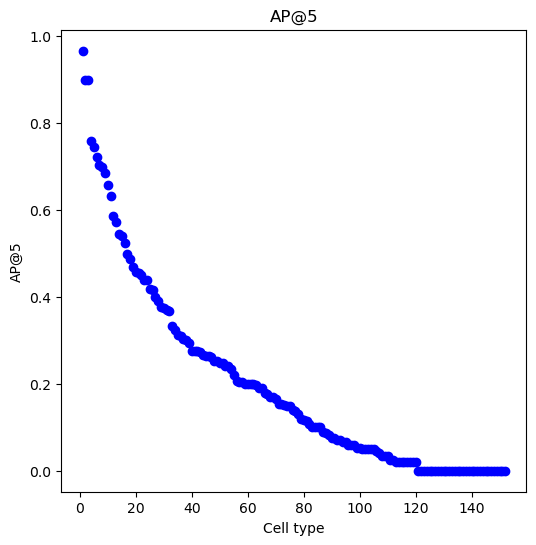

In [44]:
# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust figure size if needed

x = np.array(list(range(1, output_summary_average_df.shape[0]+1)))
y = output_summary_average_df.sort_values(by='ap_at_5', ascending = False)[['ap_at_5']]

# Plot df1
plt.scatter(x, y, label='AP', color='blue', marker='o')

# Add labels and title
plt.xlabel('Cell type')
plt.ylabel('AP@5')
plt.title('AP@5')

plt.plot([0, max(x.max(), y.max())*1.1], [0, max(x.max(), y.max())*1.1], color='red', linestyle='--', label='45-degree line')

plt.xlim([0, max(x.max(), y.max())*1.1])
plt.ylim([0, max(x.max(), y.max())*1.1])

# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

### trying to decide if it possible to extract per-cell-type count in train (impossible without more significant changes?)


train.run_finetune

train.finetune_train_stage

train_utils.training_and_validation, or metrics_utils.save_torch_train_val_preds -> get_metrics (which had celltype = 'training', i.e. no variation in cell type)

### [closed]: how to extract count by celltype for train?

In [55]:
res['positive_count_train']

{'celltype': 1883.0}

In [56]:
res['total_count_train']

{'celltype': 37015}

In [54]:
res['positive_count_test']

{'adipocyte': 4,
 'adventitial cell': 4,
 'alveolar fibroblast': 4,
 'artery endothelial cell': 6,
 'b cell': 3,
 'basal cell': 3,
 'basal cell of prostate epithelium': 3,
 'bladder urothelial cell': 6,
 'bronchial smooth muscle cell': 3,
 'bronchial vessel endothelial cell': 6,
 'capillary endothelial cell': 4,
 'cardiac endothelial cell': 4,
 'cardiac muscle cell': 4,
 'cd141-positive myeloid dendritic cell': 9,
 'cd1c-positive myeloid dendritic cell': 9,
 'cd24 neutrophil': 4,
 'cd4-positive helper t cell': 7,
 'cd4-positive, alpha-beta memory t cell': 8,
 'cd8-positive, alpha-beta cytokine secreting effector t cell': 6,
 'cd8-positive, alpha-beta cytotoxic t cell': 8,
 'cell of skeletal muscle': 6,
 'ciliary body': 3,
 'ciliated cell': 2,
 'ciliated epithelial cell': 3,
 'classical monocyte': 8,
 'club cell': 2,
 'club cell of prostate epithelium': 2,
 'conjunctival epithelial cell': 5,
 'connective tissue cell': 4,
 'corneal epithelial cell': 5,
 'corneal keratocyte': 5,
 'dendrit

## 10 repetitions of finetune, using downloaded embeds

Mar 5, 2025, 22:31

In [19]:
args.num_epoch = 2000
for _random_state in range(1,10):
    print(_random_state)
    res, output_results_path = finetune_embed(args, _random_state)
    output_summary_df = finetune_embed_output_processing(res, output_results_path)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/yang1641/.netrc


1
{'lr': 0.001, 'wd': 0.0001, 'hidden_dim_1': 32, 'hidden_dim_2': 8, 'hidden_dim_3': 0, 'dropout': 0.4, 'actn': 'relu', 'order': 'nd', 'norm': 'ln', 'task_name': 'EFO_0003767'}
Problem at: /tmp/ipykernel_3015207/60350095.py 18 finetune_embed


Traceback (most recent call last):
  File "/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/wandb/sdk/wandb_init.py", line 1078, in init
    run = wi.init()
  File "/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/wandb/sdk/wandb_init.py", line 574, in init
    manager._inform_init(settings=self.settings, run_id=self.settings.run_id)
  File "/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/wandb/sdk/wandb_manager.py", line 170, in _inform_init
    svc_iface._svc_inform_init(settings=settings, run_id=run_id)
  File "/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/wandb/sdk/service/service_sock.py", line 38, in _svc_inform_init
    self._sock_client.send(inform_init=inform_init)
  File "/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/wandb/sdk/lib/sock_client.py", line 211, in send
    self.send_server_request(server_req)
  File "/home/yang1641/.conda/envs/pinnacle/lib/python3.8/site-packages/wandb/sdk/lib/sock_

Exception: problem

# TODO: extract train loss and compare with the train loss when using downloaded embed


epoch 200: 0.1808 vs 0.1808

epoch 900, train loss is 0.1672 (similar to 0.1674)

epoch 1100, train loss is 0.1628, higher than download embed (0.1604)

epoch 1500: 0.1550 vs 0.1513

epoch 1600: 0.1524 vs 0.1494

epoch 1700: 0.1489 vs 0.1481

epoch 1800: 0.1484 vs 0.1433

epoch 1900: 0.1468 vs 0.1418

epoch 2000: 0.1424 vs 0.1419

# compare with results with author's results

### Using my embeds (trained with context ai code)

/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/tmp_evaluation_resultstry1_seed=1/try1_EFO_0000685_results.csv

### using downloaded embeds (trained by author)

/home/yang1641/PINNACLE/finetune_pinnacle/tmp_evaluation_results/pinnacle_seed=1/pinnacle_EFO_0000685_results.csv

In [52]:
output_results_path

'/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/EFO_0003767/tmp_evaluation_resultstry1_seed=1/try1_EFO_0003767_results.csv'

In [53]:
# my results
output_results_path = '/scratch/gilbreth/yang1641/exome/results/pinnacle/reproduce/epoch250/EFO_0003767/tmp_evaluation_resultstry1_seed=1/try1_EFO_0003767_results.csv'
ap_auroc_df = pd.read_csv(output_results_path)
ap_auroc_df

,cell,ap,auroc
0,adipocyte,0.135801,0.614286
1,adventitial cell,0.075207,0.558219
2,alveolar fibroblast,0.115959,0.479167
3,artery endothelial cell,0.107538,0.520833
4,b cell,0.241703,0.400000
...,...,...,...
147,type i nk t cell,0.437587,0.446429
148,type i pneumocyte,0.212679,0.713333
149,type ii pneumocyte,0.092683,0.577206
150,vascular associated smooth muscle cell,0.126984,0.833333


In [54]:
# author's results (using downloaded embeds)
import json

with open('/home/yang1641/PINNACLE/finetune_pinnacle/tmp_evaluation_results/pinnacle_seed=1/pinnacle_EFO_0003767_results.csv') as f:
    d_author = json.load(f)
    print(d_author)

{'ap': {'adipocyte': 0.04642335365226611, 'adventitial cell': 0.0583561546196896, 'alveolar fibroblast': 0.12834281650071125, 'artery endothelial cell': 0.12742537313432833, 'b cell': 0.4658119658119658, 'basal cell': 0.03331456456456457, 'basal cell of prostate epithelium': 0.07393483709273183, 'bladder urothelial cell': 0.13633247345177363, 'bronchial smooth muscle cell': 0.13333333333333333, 'bronchial vessel endothelial cell': 0.15407947281876289, 'capillary endothelial cell': 0.11696428571428572, 'cardiac endothelial cell': 0.08954045638106359, 'cardiac muscle cell': 0.34205133735979293, 'cd141-positive myeloid dendritic cell': 0.18902039685468727, 'cd1c-positive myeloid dendritic cell': 0.23115703063340723, 'cd24 neutrophil': 0.06725108225108226, 'cd4-positive helper t cell': 0.35234867471709574, 'cd4-positive, alpha-beta memory t cell': 0.6180767761650114, 'cd8-positive, alpha-beta cytokine secreting effector t cell': 0.5774712002972873, 'cd8-positive, alpha-beta cytotoxic t cel

In [55]:
ap_auroc_df_author = pd.merge(
    pd.DataFrame(list(d_author['ap'].items()), columns=['cell', 'ap']), 
    pd.DataFrame(list(d_author['auroc'].items()), columns=['cell', 'auroc'])
)

In [56]:
ap_auroc_df_author

,cell,ap,auroc
0,adipocyte,0.046423,0.307143
1,adventitial cell,0.058356,0.476027
2,alveolar fibroblast,0.128343,0.437500
3,artery endothelial cell,0.127425,0.549479
4,b cell,0.465812,0.333333
...,...,...,...
147,type i nk t cell,0.363641,0.455357
148,type i pneumocyte,0.096407,0.550000
149,type ii pneumocyte,0.100096,0.536765
150,vascular associated smooth muscle cell,0.057329,0.475000


In [64]:
ap_auroc_df_author.sort_values(by=['ap', 'auroc'], ascending=[False, False])

,cell,ap,auroc
32,dn1 thymic pro-t cell,0.633797,0.713333
17,"cd4-positive, alpha-beta memory t cell",0.618077,0.673077
18,"cd8-positive, alpha-beta cytokine secreting effector t cell",0.577471,0.722222
109,pancreatic acinar cell,0.529412,0.724138
62,immune cell,0.521601,0.629630
97,muscle cell,0.521277,0.567308
68,intestinal tuft cell,0.500000,0.967742
4,b cell,0.465812,0.333333
124,regulatory t cell,0.409582,0.731429
43,enterocyte of epithelium of large intestine,0.408036,0.517241


In [65]:
ap_auroc_df.sort_values(by=['ap', 'auroc'], ascending=[False, False])

,cell,ap,auroc
65,intestinal crypt stem cell of large intestine,0.861111,0.945652
106,nk cell,0.595238,0.843750
32,dn1 thymic pro-t cell,0.557324,0.506667
52,fibroblast of cardiac tissue,0.533333,0.641026
95,mucus secreting cell,0.523256,0.633929
81,lung ciliated cell,0.520408,0.548077
111,pancreatic beta cell,0.516129,0.661111
19,"cd8-positive, alpha-beta cytotoxic t cell",0.500266,0.657407
87,mature nk t cell,0.498044,0.633333
140,sperm,0.494444,0.796610


## compare

In [57]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [58]:
ap_auroc_df['ap']

0      0.135801
1      0.075207
2      0.115959
3      0.107538
4      0.241703
         ...   
147    0.437587
148    0.212679
149    0.092683
150    0.126984
151    0.100287
Name: ap, Length: 152, dtype: float64

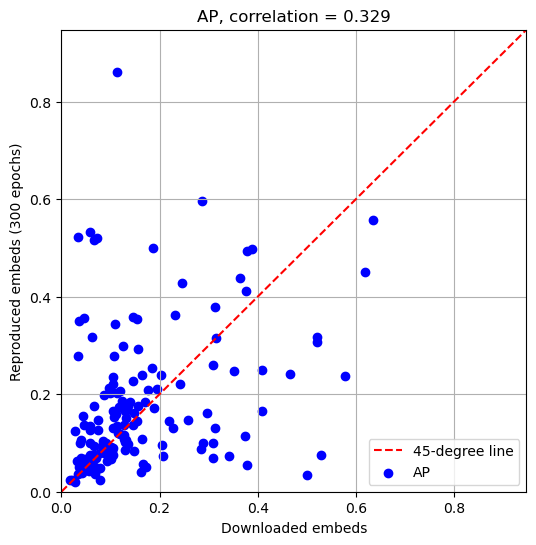

In [59]:
# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust figure size if needed

x = ap_auroc_df_author['ap']
y = ap_auroc_df['ap']

# Plot df1
plt.scatter(x, y, label='AP', color='blue', marker='o')

# Add labels and title
plt.xlabel('Downloaded embeds')
plt.ylabel('Reproduced embeds (300 epochs)')
plt.title('AP, correlation = ' + (str(round(x.corr(y), 4 ))))

plt.plot([0, max(x.max(), y.max())*1.1], [0, max(x.max(), y.max())*1.1], color='red', linestyle='--', label='45-degree line')

plt.xlim([0, max(x.max(), y.max())*1.1])
plt.ylim([0, max(x.max(), y.max())*1.1])

# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

In [ ]:
# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust figure size if needed

x = ap_auroc_df_author['auroc']
y = ap_auroc_df['auroc']

# Plot df1
plt.scatter(x, y, label='AUROC', color='blue', marker='o')

# Add labels and title
plt.xlabel('Downloaded embeds')
plt.ylabel('Reproduced embeds (300 epochs)')
plt.title('AUROC, correlation = ' + (str(round(x.corr(y), 4 ))))

plt.plot([0, max(x.max(), y.max())*1.1], [0, max(x.max(), y.max())*1.1], color='red', linestyle='--', label='45-degree line')

plt.xlim([0, max(x.max(), y.max())*1.1])
plt.ylim([0, max(x.max(), y.max())*1.1])

# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

# evaluate